<a href="https://colab.research.google.com/github/mbenedicto99/Python4DataScience/blob/master/BENE_T1_Redes_avancadas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho #1 - Rede residual e ajuste de modelo

Nesse trabalho você vai criar uma rede residual para realizar uma tarefa de classificação de múltiplas classes.

A tarefa consiste em classificar objetos do conjunto de dados CIFAR100

Esse trabalho é dividido nas seguintes etapas:

1. Explorar as imagens do conjunto de dados;
2. Construir e treinar uma rede residual para identificar o objeto mostrado na imagem;
3. Avaliar o desempenho da rede;
4. Ajustar o modelo para melhorar o desempenho.

### Importação das principais bibliotecas

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
tf.__version__

'2.19.0'

## 1. Conjunto de dados

O conjunto de dados CIFAR10 é composto por imagens coloridas de dimensão (32, 32, 3).

Esse conjunto de imagens é dedicado à classificçaõ multiclasse com 10 tipos de objetos.

Execute a célula abaixo para carregar o conjunto de dados CIFAR-10, que já está disponível diretamente no Keras.

In [7]:
# Importar conjunto de dados
from tensorflow.keras.datasets import cifar10

# Carregar o conjunto de dados CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Execute a célula abaixo para visualizar algumas imagens.

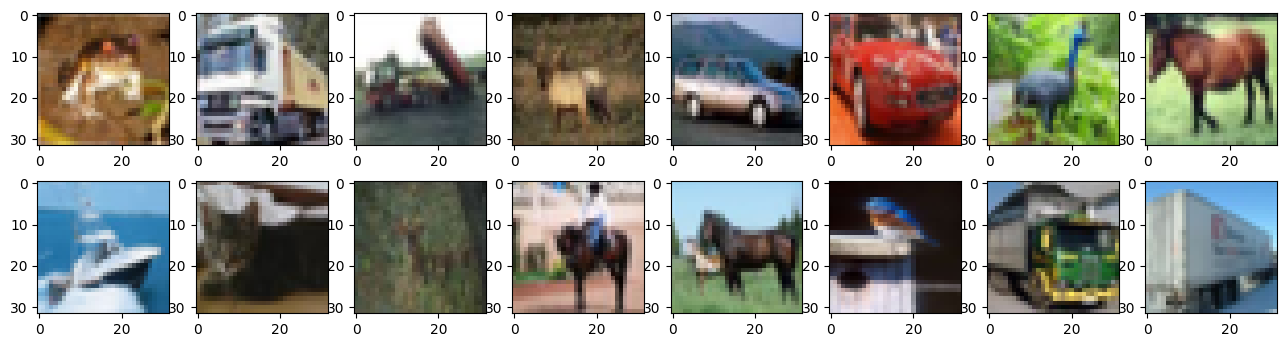

In [8]:
fig, axs = plt.subplots(2, 8, figsize=(16, 4))
index = 0
for i in range(2):
    for j in range(8):
        axs[i,j].imshow(x_train[index])
        index += 1
plt.show()

### Exercício #1: Pré-processamento dos dados

Na célula abaixo crie um código para realizar o seguinte:

1. Normalizar as imagens de forma que os seus pixels sejam valores reais entre 0 e 1;

2. Codificação one-hot das saídas.

In [9]:
# PARA VOCÊ FAZER: Normalização das imagens e codificação one-hot das saídas
# Importa função to_categorical
from tensorflow.keras.utils import to_categorical

# Normalização das imagens
### COMECE AQUI #### (~2 linhas)
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm  = x_test.astype("float32") / 255.0
### TERMINE AQUI ###

# Converter as classe para one-hot encoding
### COMECE AQUI #### (~2 linhas)
y_train_hot = to_categorical(y_train, num_classes=10)
y_test_hot  = to_categorical(y_test,  num_classes=10)
### TERMINE AQUI ###

print(f"Dimensão do conjunto de treinamento: {x_train_norm.shape}")
print(f"Dimensão do conjunto de teste: {x_test_norm.shape}")
print(f"Dimensão das saídas de treinamento: {y_train_hot.shape}")
print(f"Dimensão das saídas de teste: {y_test_hot.shape}")
print('Valores máximos e mínimos das imagens de treinamento:', np.max(x_train_norm), ',', np.min(x_train_norm))
print('Valores máximos e mínimos das imagens de teste:', np.max(x_test_norm), ',',  np.min(x_test_norm))

Dimensão do conjunto de treinamento: (50000, 32, 32, 3)
Dimensão do conjunto de teste: (10000, 32, 32, 3)
Dimensão das saídas de treinamento: (50000, 10)
Dimensão das saídas de teste: (10000, 10)
Valores máximos e mínimos das imagens de treinamento: 1.0 , 0.0
Valores máximos e mínimos das imagens de teste: 1.0 , 0.0


**Saída esperada:**

    Dimensão do conjunto de treinamento: (50000, 32, 32, 3)
    Dimensão do conjunto de teste: (10000, 32, 32, 3)
    Dimensão das saídas de treinamento: (50000, 10)
    Dimensão das saídas de teste: (10000, 10)
    Valores máximos e mínimos das imagens: 1.0 0.0

## 2. Configuração do modelo

Nesse trabalho você vai criar uma rede residual com camadas densas.

Uma rede residual é composta por blocos residuais. Na Figura 1, é mostrado um bloco residual.

ASa equações que impelementam esse bloco são as seguintes:

$$a^{[l+1]} = dense(a^{[l]})$$
$$z^{[l+2]} = dense(a^{[l]})$$
$$a^{[l+2]} = g^{[l+2]}(z^{[l+2]} + a^{[l]}))$$

onde $dense$ é uma camada densa. Observe que a função de ativação da segunda camada densa do bloco somente é aplicada após a soma das ativações $a^{[l]}$ e dos estados $z^{[l+2]}$.

A camada `layers.Add()` do Keras realiza a soma de dois tensores.

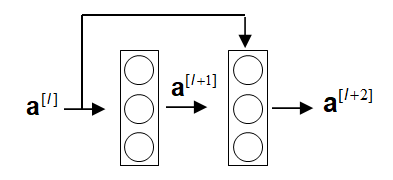

Figura 1 - Esquema de um bloco residual.

### Exercício #2: Codificação do bloco residual

Na célula abaixo crie uma função que implementa o bloco residual mostrado na Figura 1. Use a função de ativação relu.

In [10]:
### PARA VOCÊ FAZER: Definir o bloco residual
# Importa classe de camadas e modelos
from tensorflow.keras import layers, models

# Importa função de ativação
from tensorflow.keras.activations import relu

def residual_block(x, units):
    # Primeira camada densa
    ### COMECE AQUI ### (1 linha)
    a1 = layers.Dense(units, activation=relu)(x)
    ### TERMINE AQUI ###

    # Segunda camada densa sem ativação
    ### COMECE AQUI ### (1 linha)
    z2 = layers.Dense(units, activation=None)(a1)
    ### TERMINE AQUI ###

    # Soma entrada com z2 com saída da segunda camada
    ### COMECE AQUI ### (1 linha)
    s = layers.Add()([z2, x])
    ### TERMINE AQUI ###

    # Aplica função de ativação
    ### COMECE AQUI ### (1 linha)
    a2 = relu(s)
    ### TERMINE AQUI ###

    return a2

Execute a célula abaixo para testar o seu bloco residual.

In [11]:
np.random.seed(3)
x = np.random.randn(3,5)
a2 = residual_block(x, 5)
print('x:', x, '\n')
print('a2:', a2)

x: [[ 1.78862847  0.43650985  0.09649747 -1.8634927  -0.2773882 ]
 [-0.35475898 -0.08274148 -0.62700068 -0.04381817 -0.47721803]
 [-1.31386475  0.88462238  0.88131804  1.70957306  0.05003364]] 

a2: tf.Tensor(
[[1.1548581  0.22367875 1.3637617  0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.09679699 2.3780916  0.45567083 0.8708396 ]], shape=(3, 5), dtype=float32)


**Saída esperada:**

    x: [[ 1.78862847  0.43650985  0.09649747 -1.8634927  -0.2773882 ]
    [-0.35475898 -0.08274148 -0.62700068 -0.04381817 -0.47721803]
    [-1.31386475  0.88462238  0.88131804  1.70957306  0.05003364]]

    a2: tf.Tensor(
    [[1.6887243  0.5611134  0.5987834  0.         0.67116445]
    [0.         0.03314844 0.         0.1769045  0.        ]
    [0.3389045  0.16169035 0.         0.7670167  0.        ]], shape=(3, 5), dtype=float32)

### Exercício #3: Configuração da rede

A rede que será utilizada será composta por 2 blocos residuais, sendo que entre eles deve ter um camada densa para ajustar a dimensão dos dados.

Na célula abaixo crie uma função para gerar a rede residual. Essa função deve receber o seguinte:

1. Dimensão das imagens de entrada;
2. lista com número de unidades em cada bloco e cada camada da rede;
3. Número de classes para definir o número de unidades da camada de saída;
4. Exceto na camada de saída utiliza função de ativação relu.

In [12]:
### PARA VOCÊ FAZER: Definir a arquitetura do modelo

def create_residual_model(n1, n2, num_classes, input_shape=(32, 32, 3)):
    ### COMECE AQUI ###
    # Camada de entrada
    inputs = layers.Input(shape=input_shape)
    # Camada para esticar imagem
    x = layers.Flatten()(inputs)
    # Primeira camada densa
    x = layers.Dense(n1, activation=relu)(x)
    # Primeiro bloco residual
    x = residual_block(x, n1)
    # Camada densa
    x = layers.Dense(n2, activation=relu)(x)
    # Segundo bloco residual
    x = residual_block(x, n2)
    # Camada de saída
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    # Construir o modelo
    model = models.Model(inputs=inputs, outputs=outputs)
    ### TERMINE AQUI ###

    return model


Para criar o modelo, utilize a função `create_residual_model()` com os seguintes parâmetros:

- n1 = 256;
- n2 = 128;
- num_classes = 10.


In [13]:
# PARA VOCE FAZER: Criar modelo

# Definir parâmetros
### PARA VOCE FAZER ### (3 linhas)
n1 = 256
n2 = 128
num_classes = 10
### TERMINE AQUI ###

# Criar modelo
### PARA VOCE FAZER ### (1 linha)
rna = create_residual_model(n1, n2, num_classes, input_shape=(32, 32, 3))
### TERMINE AQUI ###

rna. summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3072)      │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    786,688 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     65,792 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256)       │          0 │ dense_4[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256)       │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     32,896 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     16,512 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     16,512 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 128)       │          0 │ dense_7[0][0],    │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128)       │          0 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 10)        │      1,290 │ re_lu_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 985,482 (3.76 MB)

 Trainable params: 985,482 (3.76 MB)

 Non-trainable params: 0 (0.00 B)

**Saída esperada:**

    Model: "functional"
    ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
    ┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
    ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
    │ input_layer_1             │ (None, 32, 32, 3)      │              0 │ -                      │
    │ (InputLayer)              │                        │                │                        │
    ├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
    │ flatten_1 (Flatten)       │ (None, 3072)           │              0 │ input_layer_1[0][0]    │
    ├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
    │ dense_12 (Dense)          │ (None, 256)            │        786,688 │ flatten_1[0][0]        │
    ├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
    │ dense_13 (Dense)          │ (None, 256)            │         65,792 │ dense_12[0][0]         │
    ├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
    │ dense_14 (Dense)          │ (None, 256)            │         65,792 │ dense_13[0][0]         │
    ├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
    │ add_6 (Add)               │ (None, 256)            │              0 │ dense_12[0][0],        │
    │                           │                        │                │ dense_14[0][0]         │
    ├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
    │ activation_4 (Activation) │ (None, 256)            │              0 │ add_6[0][0]            │
    ├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
    │ dense_15 (Dense)          │ (None, 128)            │         32,896 │ activation_4[0][0]     │
    ├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
    │ dense_16 (Dense)          │ (None, 128)            │         16,512 │ dense_15[0][0]         │
    ├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
    │ dense_17 (Dense)          │ (None, 128)            │         16,512 │ dense_16[0][0]         │
    ├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
    │ add_7 (Add)               │ (None, 128)            │              0 │ dense_15[0][0],        │
    │                           │                        │                │ dense_17[0][0]         │
    ├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
    │ activation_5 (Activation) │ (None, 128)            │              0 │ add_7[0][0]            │
    ├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
    │ dense_18 (Dense)          │ (None, 10)             │          1,290 │ activation_5[0][0]     │
    └───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘
    Total params: 985,482 (3.76 MB)
    Trainable params: 985,482 (3.76 MB)
    Non-trainable params: 0 (0.00 B)

## 3. Compilação e treinamento do modelo

### Exercício #4: Compilação do modelo

Agora que o modelo foi criado, você precisa compilá-lo. Vamos usar a função de perda `categorical_crossentropy` para classificação multiclasse e o otimizador `Adam`.

In [14]:
# PARA VOCE FAZER: Compilar o modelo

### COMECE AQUI ### (1 comando)
rna.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
### TERMINE AQUI ###

### Exercício #5: Treinar o modelo

Para treinar o modelo use 100 épocas e um lote de 256 exemplos.

In [15]:
# PARA VOCE FAZER: Treinar o modelo

### COMECE AQUI ### (1 comando)
history = rna.fit(x_train_norm, y_train_hot, epochs=100, batch_size=256, validation_data=(x_test_norm, y_test_hot), verbose=1)
### TERMINE AQUI ###

Epoch 1/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.2384 - loss: 2.1039 - val_accuracy: 0.3805 - val_loss: 1.7318
Epoch 2/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3858 - loss: 1.7179 - val_accuracy: 0.4079 - val_loss: 1.6660
Epoch 3/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4149 - loss: 1.6216 - val_accuracy: 0.4528 - val_loss: 1.5379
Epoch 4/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4435 - loss: 1.5505 - val_accuracy: 0.4492 - val_loss: 1.5648
Epoch 5/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4672 - loss: 1.5011 - val_accuracy: 0.4507 - val_loss: 1.5331
Epoch 6/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4748 - loss: 1.4567 - val_accuracy: 0.4732 - val_loss: 1.4787
Epoch 7/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4875 - loss: 1.4268 - val_accuracy: 0.4865 - val_loss: 1.4409
Epoch 8/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5043 - loss: 1.3831 - val_acc

**Saída esperada:**

    Epoch 1/100
    196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.2288 - loss: 2.1627 - val_accuracy: 0.3783 - val_loss: 1.7425
    Epoch 2/100
    196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3720 - loss: 1.7419 - val_accuracy: 0.4168 - val_loss: 1.6358
    .
    .
    .
    Epoch 99/100
    196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9347 - loss: 0.1806 - val_accuracy: 0.4800 - val_loss: 4.0803
    Epoch 100/100
    196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9350 - loss: 0.1817 - val_accuracy: 0.4942 - val_loss: 4.1091

Execute a célula abaixo para vizualizar os gráficos do processo de treinamento.

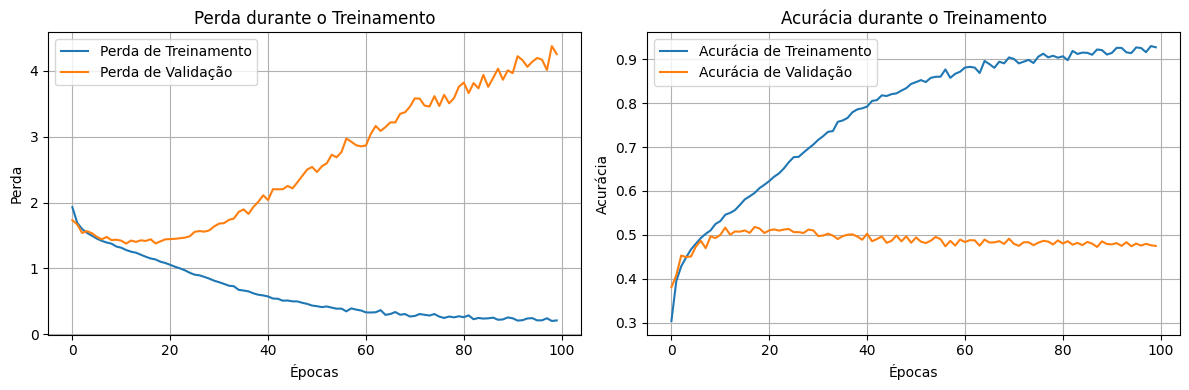

In [16]:
# Plotar a perda e acurácia durante o treinamento
plt.figure(figsize=(12, 4))

# Plotando a perda
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Perda de Treinamento')
plt.plot(history.history['val_loss'], label='Perda de Validação')
plt.title('Perda durante o Treinamento')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.grid()
plt.legend()

# Plotando a acurácia
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Acurácia de Treinamento')
plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
plt.title('Acurácia durante o Treinamento')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

### Exercício #6: Avaliar o modelo

Use o método evaluate e calcule a função de custo e a métrica para os dados de treinamento e teste.

In [17]:
### PARA VOCE FAZER: Avaliar o modelo

### COMECE AQUI ### (2 linhas)
train_loss, train_acc = rna.evaluate(x_train_norm, y_train_hot, verbose=0)
test_loss,  test_acc  = rna.evaluate(x_test_norm,  y_test_hot,  verbose=0)
### TERMINE AQUI ###

**Saída esperada:**

    1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9438 - loss: 0.1639
    313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4957 - loss: 4.0715

## 4. Ajuste do modelo

Você agora tem um modelo básico de rede residual para classificação de imagens no conjunto CIFAR100. Por meio da adição de blocos residuais, o modelo pode ser mais profundo sem enfrentar problemas de degradação do desempenho.

Com base nesse modelo, você pode fazer experimentos adicionais para melhorar a performance, como ajustar a arquitetura, adicionar camadas de normalização, ou utilizar técnicas de data augmentation.

### Exercício #7: Ajustar o modelo para obter resultados melhores

Nesse exercício você deve fazer ajustes no modelo para melhorar o seu desempenho. As possíveis modificações são: adicionar mais blocos residuais, mudar o número de unidades nos blocos e nas camadas densas, ou tentar diferentes técnicas de regularização (dropout, L2 regularization etc.)  Além disso, é possível testar diferentes algoritmos de otimização e taxas de aprendizado.

Implemente as seguintes modificações no modelo:

1. Aumentar número de blocos residuais e aumentar número de unidades nas camadas;
2. Incluir camadas de dropout no modelo maior do item (1);
3. Retirar as camadas de dropout e aplicar regularização L2 no modelo maior do item(1).

Para cada modificação você deve apresentar o novo modelo, a compilação, o treinamento e a avaliação.

A sua avaliação nesse exercício depende dos resultados de exatidão nos dados de teste.

Analise os resultados do ajuste do modelo.

In [19]:
"""
Residual MLP para CIFAR-10/100 com blocos residuais densos.
Variações:
  (A) Mais blocos e unidades (baseline, sem regularização)
  (B) (A) + Dropout
  (C) (A) + L2 regularization
Callbacks: EarlyStopping e ReduceLROnPlateau.
"""

# =========================
# Imports
# =========================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.activations import relu
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print("TensorFlow:", tf.__version__)

# =========================
# Configurações
# =========================
USE_CIFAR100 = True          # True -> CIFAR-100, False -> CIFAR-10
EPOCHS = 100
BATCH_SIZE = 256
INPUT_SHAPE = (32, 32, 3)

# =========================
# Dataset
# =========================
if USE_CIFAR100:
    from tensorflow.keras.datasets import cifar100
    (x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode="fine")
else:
    from tensorflow.keras.datasets import cifar10
    (x_train, y_train), (x_test, y_test) = cifar10.load_data()

num_classes = int(np.max(y_train)) + 1
assert num_classes in (10, 100), f"num_classes inesperado: {num_classes}"

# Normalização [0,1]
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm  = x_test.astype("float32") / 255.0

# One-hot
y_train_hot = to_categorical(y_train, num_classes=num_classes)
y_test_hot  = to_categorical(y_test,  num_classes=num_classes)

# Sanidade
assert x_train_norm.shape[1:] == INPUT_SHAPE and x_test_norm.shape[1:] == INPUT_SHAPE
assert y_train_hot.shape[1] == num_classes and y_test_hot.shape[1] == num_classes

print("Train:", x_train_norm.shape, y_train_hot.shape, "| Test:", x_test_norm.shape, y_test_hot.shape)

# =========================
# Bloco Residual Denso (com projeção no atalho)
# =========================
def residual_block(x, units, kernel_regularizer=None, name=None):
    """
    h1 = Dense(units, relu)
    h2 = Dense(units, linear)
    if x.shape[-1] != units: shortcut = Dense(units, linear)(x)  # projeção
    out = relu(h2 + shortcut)
    """
    h = layers.Dense(units, activation=relu, kernel_regularizer=kernel_regularizer,
                     name=None if not name else f"{name}_dense1")(x)
    h = layers.Dense(units, activation=None, kernel_regularizer=kernel_regularizer,
                     name=None if not name else f"{name}_dense2")(h)

    if x.shape[-1] != units:
        shortcut = layers.Dense(units, activation=None, kernel_regularizer=kernel_regularizer,
                                name=None if not name else f"{name}_proj")(x)
    else:
        shortcut = x

    s = layers.Add(name=None if not name else f"{name}_add")([h, shortcut])
    return relu(s)

# =========================
# Arquitetura do Modelo Residual
# =========================
def create_residual_model(
    blocks_units,              # ex.: [1024, 1024, 512]
    dense_between=None,        # ex.: [768, 512] (entre blocos)
    num_classes=10,
    input_shape=INPUT_SHAPE,
    dropout_rate=None,         # ex.: 0.3
    l2_lambda=None,            # ex.: 1e-4
    use_augment=True
):
    kr = regularizers.l2(l2_lambda) if l2_lambda else None

    inputs = layers.Input(shape=input_shape)

    x = inputs
    if use_augment:
        x = layers.RandomFlip("horizontal")(x)
        x = layers.RandomRotation(0.05)(x)
        x = layers.RandomZoom(0.1)(x)

    x = layers.Flatten()(x)

    # bootstrap para a largura do primeiro bloco
    x = layers.Dense(blocks_units[0], activation=relu, kernel_regularizer=kr,
                     name="bootstrap_dense")(x)
    if dropout_rate:
        x = layers.Dropout(dropout_rate, name="drop_after_bootstrap")(x)

    # Sequência de blocos + densas intermediárias
    for i, units in enumerate(blocks_units):
        x = residual_block(x, units, kernel_regularizer=kr, name=f"res{i+1}")
        if dropout_rate:
            x = layers.Dropout(dropout_rate, name=f"drop_after_res{i+1}")(x)

        # Entre blocos (se houver próximo) ajuste de dimensão opcional
        if dense_between and i < len(dense_between):
            x = layers.Dense(dense_between[i], activation=relu, kernel_regularizer=kr,
                             name=f"between_dense{i+1}")(x)
            if dropout_rate:
                x = layers.Dropout(dropout_rate, name=f"drop_after_between{i+1}")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="logits")(x)
    model = models.Model(inputs=inputs, outputs=outputs, name="ResidualMLP")
    return model

def compile_model(model, lr=1e-3, optimizer="adam"):
    if isinstance(optimizer, str) and optimizer.lower() == "adam":
        opt = tf.keras.optimizers.Adam(learning_rate=lr)
    else:
        opt = optimizer
    model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
    return model

def train_and_evaluate(model, tag, x_train, y_train, x_test, y_test,
                       epochs=EPOCHS, batch_size=BATCH_SIZE):
    print(f"\n===== Treinando {tag} =====")
    es  = EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True)
    rlr = ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, patience=5, min_lr=1e-5)
    hist = model.fit(
        x_train, y_train,
        validation_data=(x_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        verbose=2,
        callbacks=[es, rlr],
    )
    print(f"\n===== Avaliando {tag} =====")
    train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
    test_loss,  test_acc  = model.evaluate(x_test,  y_test,  verbose=0)
    print(f"{tag}  ->  Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")
    return {"tag": tag, "train_loss": train_loss, "train_acc": train_acc,
            "test_loss": test_loss, "test_acc": test_acc, "history": hist.history}

def summarize_results(*results):
    print("\n===== Resumo (ordenado por Test Acc) =====")
    order = sorted(results, key=lambda d: d["test_acc"], reverse=True)
    for r in order:
        print(f"{r['tag']:<38} | Test Acc: {r['test_acc']:.4f} | Train Acc: {r['train_acc']:.4f}")

# =========================
# (A) Modelo MAIOR — mais blocos e unidades (sem reg.)
# =========================
model_A = create_residual_model(
    blocks_units=[1024, 1024, 512],
    dense_between=[768, 512],
    num_classes=num_classes,
    input_shape=INPUT_SHAPE,
    dropout_rate=None,
    l2_lambda=None,
    use_augment=True
)
compile_model(model_A, lr=1e-3, optimizer="adam")
model_A.summary()
res_A = train_and_evaluate(model_A, "A: deeper+bigger (sem reg.)",
                           x_train_norm, y_train_hot, x_test_norm, y_test_hot)

# =========================
# (B) (A) + Dropout
# =========================
model_B = create_residual_model(
    blocks_units=[1024, 1024, 512],
    dense_between=[768, 512],
    num_classes=num_classes,
    input_shape=INPUT_SHAPE,
    dropout_rate=0.3,      # Dropout moderado
    l2_lambda=None,
    use_augment=True
)
compile_model(model_B, lr=1e-3, optimizer="adam")
res_B = train_and_evaluate(model_B, "B: deeper+bigger + Dropout(0.3)",
                           x_train_norm, y_train_hot, x_test_norm, y_test_hot)

# =========================
# (C) (A) + L2 regularization
# =========================
model_C = create_residual_model(
    blocks_units=[1024, 1024, 512],
    dense_between=[768, 512],
    num_classes=num_classes,
    input_shape=INPUT_SHAPE,
    dropout_rate=None,
    l2_lambda=1e-4,        # L2 leve
    use_augment=True
)
compile_model(model_C, lr=1e-3, optimizer="adam")
res_C = train_and_evaluate(model_C, "C: deeper+bigger + L2(1e-4)",
                           x_train_norm, y_train_hot, x_test_norm, y_test_hot)

# =========================
# Comparativo final
# =========================
summarize_results(res_A, res_B, res_C)


TensorFlow: 2.19.0
Train: (50000, 32, 32, 3) (50000, 100) | Test: (10000, 32, 32, 3) (10000, 100)


Model: "ResidualMLP"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_1       │ (None, 32, 32, 3) │          0 │ input_layer_2[0]… │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_1   │ (None, 32, 32, 3) │          0 │ random_flip_1[0]… │
│ (RandomRotation)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom_1       │ (None, 32, 32, 3) │          0 │ random_rotation_… │
│ (RandomZoom)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 3072)      │          0 │ random_zoom_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bootstrap_dense     │ (None, 1024)      │  3,146,752 │ flatten_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_dense1 (Dense) │ (None, 1024)      │  1,049,600 │ bootstrap_dense[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_dense2 (Dense) │ (None, 1024)      │  1,049,600 │ res1_dense1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_add (Add)      │ (None, 1024)      │          0 │ res1_dense2[0][0… │
│                     │                   │            │ bootstrap_dense[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 1024)      │          0 │ res1_add[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ between_dense1      │ (None, 768)       │    787,200 │ re_lu_3[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_dense1 (Dense) │ (None, 1024)      │    787,456 │ between_dense1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_dense2 (Dense) │ (None, 1024)      │  1,049,600 │ res2_dense1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_proj (Dense)   │ (None, 1024)      │    787,456 │ between_dense1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_add (Add)      │ (None, 1024)      │          0 │ res2_dense2[0][0… │
│                     │                   │            │ res2_proj[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 1024)      │          0 │ res2_add[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ between_dense2      │ (None, 512)       │    524,800 │ re_lu_4[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res3_dense1 (Dense) │ (None, 512)       │    262,656 │ between_dense2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res3_dense2 (Dense) │ (None, 512)       │    262,656 │ res3_dense1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res3_add (Add)      │ (None, 512)       │          0 │ res3_dense2[0][0… │
│                     │                   │            │ between_dense2[0

 Total params: 9,759,076 (37.23 MB)

 Trainable params: 9,759,076 (37.23 MB)

 Non-trainable params: 0 (0.00 B)


===== Treinando A: deeper+bigger (sem reg.) =====
Epoch 1/100
196/196 - 10s - 52ms/step - accuracy: 0.0420 - loss: 4.3139 - val_accuracy: 0.0656 - val_loss: 4.0374 - learning_rate: 1.0000e-03
Epoch 2/100
196/196 - 3s - 17ms/step - accuracy: 0.0837 - loss: 3.9495 - val_accuracy: 0.0918 - val_loss: 3.9079 - learning_rate: 1.0000e-03
Epoch 3/100
196/196 - 3s - 17ms/step - accuracy: 0.1232 - loss: 3.7329 - val_accuracy: 0.1408 - val_loss: 3.6298 - learning_rate: 1.0000e-03
Epoch 4/100
196/196 - 3s - 17ms/step - accuracy: 0.1506 - loss: 3.5708 - val_accuracy: 0.1621 - val_loss: 3.5241 - learning_rate: 1.0000e-03
Epoch 5/100
196/196 - 3s - 16ms/step - accuracy: 0.1712 - loss: 3.4470 - val_accuracy: 0.1779 - val_loss: 3.4306 - learning_rate: 1.0000e-03
Epoch 6/100
196/196 - 3s - 17ms/step - accuracy: 0.1853 - loss: 3.3715 - val_accuracy: 0.1817 - val_loss: 3.4181 - learning_rate: 1.0000e-03
Epoch 7/100
196/196 - 3s - 16ms/step - accuracy: 0.2007 - loss: 3.2933 - val_accuracy: 0.2021 - val_lo